In [1]:
import pickle
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter

In [4]:
datasets = [
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/QBioLiP/sequence_30_split/PL",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/QBioLiP/sequence_30_split/PDNA",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/QBioLiP/sequence_30_split/PRNA",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/QBioLiP/sequence_30_split/PP",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/QBioLiP/sequence_30_split/Ppeptide",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/QBioLiP/sequence_30_split/RNAL",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/QBioLiP/sequence_30_split/Pion",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/frequency_splits_torsion_09_2024/CSD_PS_300",
]


dataset_statistics = []
for dataset in tqdm(datasets, total=len(datasets)):
    for split in ['train', 'test', 'valid']:
        dataset_statistics_ = {}
        with open(f"{dataset}_{split}.pkl", "rb") as f:
            data = pickle.load(f)
        
        dataset_statistics_['dataset'] = os.path.basename(dataset)
        dataset_statistics_['split'] = split
        dataset_statistics_['num_samples'] = len(data)

        block_sizes = np.array([len(item['data']['B']) for item in data])
        atom_sizes = np.array([len(item['data']['A']) for item in data])
        dataset_statistics_['block_sizes'] = block_sizes
        dataset_statistics_['atom_sizes'] = atom_sizes
        dataset_statistics_['max_block_size'] = max(block_sizes)
        dataset_statistics_['max_atom_size'] = max(atom_sizes)
        dataset_statistics_['min_block_size'] = min(block_sizes)
        dataset_statistics_['min_atom_size'] = min(atom_sizes)
        dataset_statistics_['avg_block_size'] = block_sizes.mean()
        dataset_statistics_['avg_atom_size'] = atom_sizes.mean()
        dataset_statistics_['std_block_size'] = block_sizes.std()
        dataset_statistics_['std_atom_size'] = atom_sizes.std()
        dataset_statistics.append(dataset_statistics_)
dataset_statistics = pd.DataFrame(dataset_statistics)

100%|██████████| 8/8 [04:28<00:00, 33.53s/it]


In [5]:
dataset_statistics

,dataset,split,num_samples,block_sizes,atom_sizes,max_block_size,max_atom_size,min_block_size,min_atom_size,avg_block_size,avg_atom_size,std_block_size,std_atom_size
0,PL,train,105090,"[44, 34, 44, 23, 47, 25, 12, 56, 12, 13, 19, 5...","[267, 176, 294, 146, 352, 140, 70, 205, 62, 94...",1082,7523,4,8,53.465287,252.035845,29.206918,122.744718
1,PL,test,6654,"[65, 21, 18, 79, 71, 72, 69, 82, 82, 77, 80, 8...","[296, 122, 133, 314, 236, 248, 209, 320, 293, ...",596,3188,4,14,45.157199,247.381876,28.673697,146.642849
2,PL,valid,7273,"[46, 24, 21, 45, 29, 48, 51, 76, 105, 53, 97, ...","[213, 177, 120, 230, 219, 111, 298, 489, 354, ...",568,808,4,9,46.256428,261.205830,26.218992,126.857860
3,PDNA,train,2253,"[36, 75, 70, 49, 54, 69, 85, 31, 116, 41, 89, ...","[426, 905, 1011, 514, 706, 946, 849, 398, 1450...",592,6466,4,7,101.203285,1191.932978,70.786724,819.159745
4,PDNA,test,249,"[185, 39, 63, 97, 186, 180, 38, 71, 21, 102, 7...","[2083, 484, 760, 1191, 2123, 1951, 495, 848, 2...",389,4434,11,106,96.718876,1139.718876,67.360873,787.999063
5,PDNA,valid,248,"[265, 58, 68, 117, 61, 57, 112, 59, 73, 39, 47...","[2778, 830, 786, 1186, 860, 814, 1467, 811, 80...",426,4660,11,100,102.520161,1229.705645,61.854600,707.881891
6,PRNA,train,2975,"[34, 55, 121, 70, 33, 57, 22, 24, 348, 44, 38,...","[529, 633, 1964, 640, 331, 721, 219, 243, 3982...",1259,11308,5,51,110.964034,1311.365378,113.791434,1286.112452
7,PRNA,test,161,"[68, 523, 30, 26, 67, 20, 42, 60, 216, 77, 133...","[1142, 5845, 311, 278, 907, 260, 388, 914, 270...",805,8400,11,135,105.633540,1226.509317,128.295209,1425.817312
8,PRNA,valid,375,"[112, 58, 355, 247, 330, 164, 401, 328, 332, 3...","[1758, 588, 3941, 3212, 3678, 1829, 4512, 4144...",736,7401,13,128,84.954667,891.357333,109.898453,1172.980950
9,PP,train,105101,"[224, 80, 70, 74, 168, 78, 29, 59, 190, 122, 1...","[1782, 577, 547, 578, 1356, 603, 228, 472, 153...",1083,7010,10,10,85.411414,669.447836,67.350660,535.141883


In [8]:
print("Total number of samples:", dataset_statistics['num_samples'].sum())
dataset_statistics.groupby("split")[['num_samples']].sum()

Total number of samples: 2105703


,num_samples
split,
test,34032
train,2037972
valid,33699


In [38]:
def concat_arrays(x):
    return np.concatenate(x.values)

dataset_statistics_summary = dataset_statistics.groupby('dataset').agg({
    'num_samples': 'sum',
    'max_block_size': 'max',
    'max_atom_size': 'max',
    'min_block_size': 'min',
    'min_atom_size': 'min',
    'atom_sizes': concat_arrays,
    'block_sizes': concat_arrays,
})

dataset_statistics_summary['mean_atom_size'] = dataset_statistics_summary['atom_sizes'].apply(lambda x: x.mean())
dataset_statistics_summary['mean_block_size'] = dataset_statistics_summary['block_sizes'].apply(lambda x: x.mean())
dataset_statistics_summary.drop(columns=['atom_sizes', 'block_sizes']).sort_values('num_samples', ascending=False)

,num_samples,max_block_size,max_atom_size,min_block_size,min_atom_size,mean_atom_size,mean_block_size
dataset,,,,,,,
CSD_PS_300,1767710,98,102,4,14,52.838699,14.832878
PP,124541,1344,10904,10,10,667.586257,85.187063
PL,119017,1082,7523,4,8,252.336019,52.560273
Pion,74514,53,358,4,7,88.111751,14.070269
Ppeptide,8475,151,1131,5,25,390.311504,50.243540
RNAL,5185,113,449,4,23,94.455159,8.037030
PRNA,3511,1259,11308,5,51,1262.614355,107.941612
PDNA,2750,592,6466,4,7,1190.611636,100.916000


In [3]:
csd_identifiers = []
prefix = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/CSD_PS_300"
for split in ['train', 'test', 'valid']:
    with open(f"{prefix}_{split}.pkl", "rb") as f:
        data = pickle.load(f)
    csd_identifiers.extend([item['id'].split("_")[0] for item in data])
print("Number of unique CSD identifiers:", len(set(csd_identifiers)))

Number of unique CSD identifiers: 375941


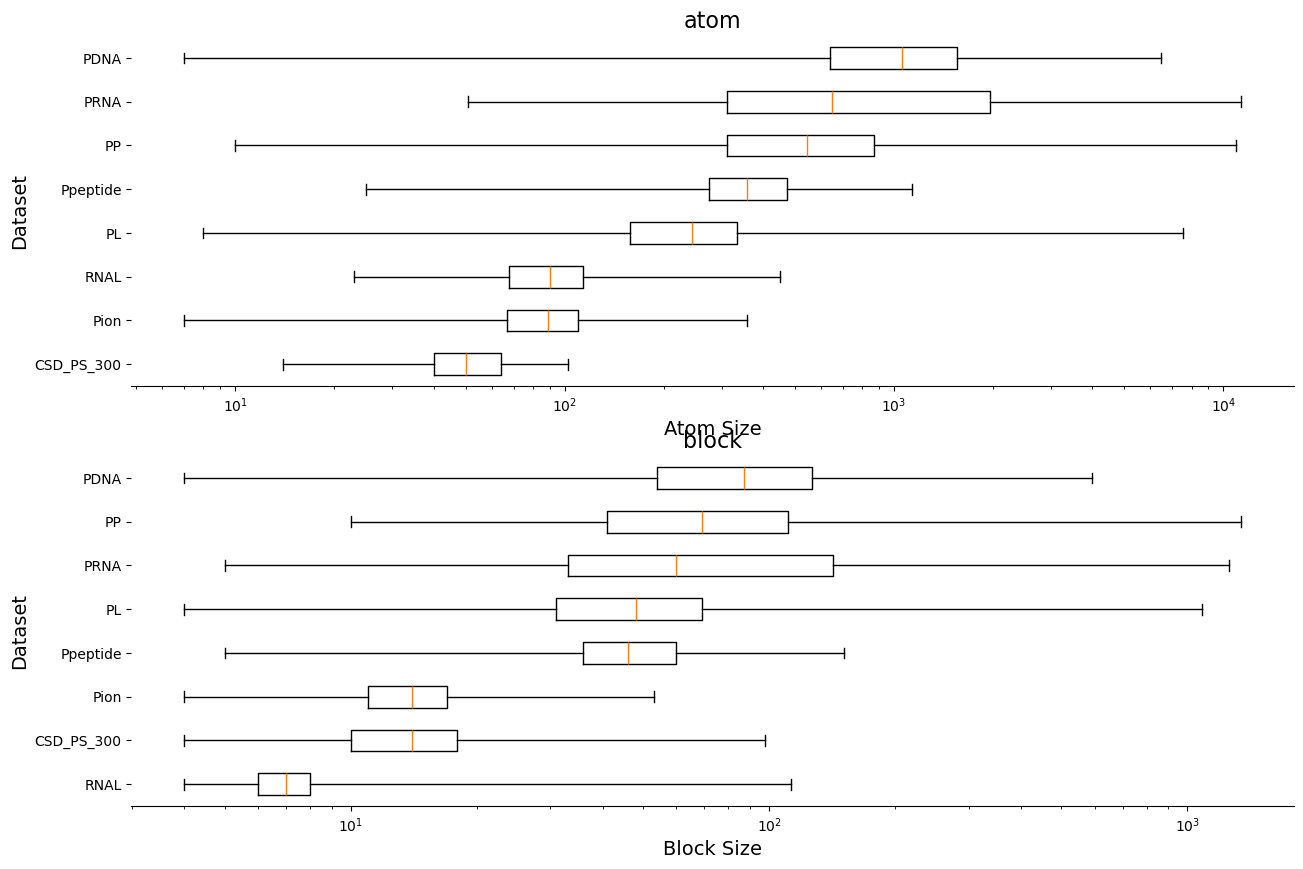

In [30]:

fig, ax = plt.subplots(figsize=(15,10), nrows=2, ncols=1)

node_types = {"atom": 0, "block": 1}

for node_type, ax_idx in node_types.items():
    node_sizes_dict = {
        dataset: np.concatenate(dataset_statistics[dataset_statistics['dataset'] == os.path.basename(dataset)][f'{node_type}_sizes'].values)
        for dataset in datasets
    }
    sorted_items = sorted(node_sizes_dict.items(), key=lambda x: np.median(x[1]))
    datasets, node_sizes = zip(*sorted_items)

    bp = ax[ax_idx].boxplot(node_sizes, vert=False, whis=[0, 100])

    ax[ax_idx].set_title(node_type, fontsize=16)
    ax[ax_idx].set_xlabel(f'{node_type.capitalize()} Size', fontsize=14)
    ax[ax_idx].set_ylabel('Dataset', fontsize=14)
    ax[ax_idx].set_yticklabels([os.path.basename(x) for x in datasets])
    ax[ax_idx].set_xscale('log')

    ax[ax_idx].spines['top'].set_visible(False)
    ax[ax_idx].spines['right'].set_visible(False)
    ax[ax_idx].spines['left'].set_visible(False)
plt.savefig("dataset_node_sizes.svg", format="svg")
plt.show()

In [2]:
datasets = [
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PL",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PDNA",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PRNA",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PP",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/Ppeptide",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/RNAL",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/Pion",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/CSD_PS_300",
]

test_ids = {}
for dataset in tqdm(datasets, total=len(datasets)):
    with open(f"{dataset}_test.pkl", "rb") as f:
        data = pickle.load(f)
    test_ids[os.path.basename(dataset)] = [item['id'] for item in data]   

100%|██████████| 8/8 [00:16<00:00,  2.03s/it]


In [16]:
'4qf3' in Counter([x.split("_")[0] for x in test_ids['Pion']])

False

In [18]:
Counter([x.split("_")[0] for x in test_ids['PRNA']]).most_common()[-100:]

[('4ang', 24),
 ('2qqp', 12),
 ('1h2c', 8),
 ('5hab', 4),
 ('4qu6', 3),
 ('3epl', 3),
 ('4db4', 2),
 ('4f1n', 2),
 ('5zse', 2),
 ('3t3n', 2),
 ('6iid', 2),
 ('7wnu', 2),
 ('2fk6', 2),
 ('4xww', 2),
 ('6llb', 2),
 ('3agv', 2),
 ('7yse', 2),
 ('6je9', 2),
 ('5jrc', 2),
 ('3fte', 1),
 ('6jdv', 1),
 ('6so9', 1),
 ('2ad9', 1),
 ('1ooa', 1),
 ('2kfy', 1),
 ('5bud', 1),
 ('7f49', 1),
 ('7v93', 1),
 ('5dv7', 1),
 ('3ol9', 1),
 ('5wt1', 1),
 ('6jdq', 1),
 ('5zw4', 1),
 ('8ibx', 1),
 ('5hc9', 1),
 ('7rsr', 1),
 ('7ndj', 1),
 ('8hnw', 1),
 ('3v74', 1),
 ('2kg1', 1),
 ('8csz', 1),
 ('8hhl', 1),
 ('4k50', 1),
 ('2e9t', 1),
 ('6je3', 1),
 ('6f3h', 1),
 ('7v94', 1),
 ('1t2r', 1),
 ('6rfl', 1),
 ('8ff4', 1),
 ('1vfg', 1),
 ('5hsw', 1),
 ('2xc7', 1),
 ('6kc7', 1),
 ('8hhm', 1),
 ('3v71', 1),
 ('3iev', 1),
 ('7a9x', 1),
 ('5bte', 1),
 ('4gcw', 1),
 ('8fzr', 1),
 ('5o1z', 1),
 ('5y6z', 1),
 ('4qu7', 1),
 ('7jtq', 1),
 ('6jfu', 1),
 ('7o0g', 1),
 ('2mqp', 1),
 ('5a0t', 1),
 ('4k4x', 1),
 ('8iby', 1),
 ('2